# 📊 E-Commerce Customer Churn Prediction
### Full ML Pipeline: Data Generation → Cleaning → EDA → Modelling → Export
---

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score)
import joblib, os, json

# Plotting style
plt.rcParams['figure.facecolor'] = '#0f1521'
plt.rcParams['axes.facecolor']   = '#161e30'
plt.rcParams['text.color']       = '#e2e8f0'
plt.rcParams['axes.labelcolor']  = '#e2e8f0'
plt.rcParams['xtick.color']      = '#e2e8f0'
plt.rcParams['ytick.color']      = '#e2e8f0'
plt.rcParams['axes.edgecolor'] = (1, 1, 1, 0.1)
plt.rcParams['grid.color'] = (1, 1, 1, 0.06)

print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Generate Synthetic Dataset (50,000 rows)

In [2]:
np.random.seed(42)
N = 50_000

# Demographics
customer_ids = [f'CUST{str(i).zfill(6)}' for i in range(1, N+1)]
ages     = np.random.normal(38, 12, N).clip(18, 75).astype(int)
genders  = np.random.choice(['Male','Female'], N, p=[0.48,0.52])
locations = np.random.choice(
    ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Pune','Kolkata','Ahmedabad'],
    N, p=[0.18,0.17,0.16,0.12,0.12,0.10,0.08,0.07]
)
payment_methods = np.random.choice(
    ['Credit Card','Debit Card','UPI','Net Banking','Wallet'],
    N, p=[0.30,0.25,0.25,0.12,0.08]
)

# Behavioural
tenure             = np.random.exponential(24, N).clip(1, 84).astype(int)
number_of_orders   = (tenure * np.random.uniform(0.5, 3.0, N)).clip(1, 300).astype(int)
avg_order_value    = np.random.lognormal(7.5, 0.6, N).clip(150, 15000).round(2)
total_spending     = (number_of_orders * avg_order_value * np.random.uniform(0.8,1.2,N)).round(2)
last_purchase_days = np.random.exponential(45, N).clip(1, 365).astype(int)
discount_used      = np.random.choice([0,1], N, p=[0.40,0.60])
satisfaction_score = np.random.choice(range(1,11), N,
    p=[0.04,0.05,0.07,0.09,0.11,0.14,0.16,0.14,0.11,0.09])
app_usage_time     = np.random.exponential(30, N).clip(0,180).round(1)
support_calls      = np.random.poisson(1.5, N).clip(0,15)
returned_orders    = (number_of_orders * np.random.beta(1.2,8,N)).astype(int)

# Churn logic
churn_score = (
     0.30 * (last_purchase_days / 365)
    -0.20 * (satisfaction_score / 10)
    +0.15 * (support_calls / 15)
    -0.10 * (app_usage_time / 180)
    +0.10 * (returned_orders / (number_of_orders + 1))
    -0.05 * (tenure / 84)
    +0.05 * (1 - discount_used * 0.5)
    +np.random.normal(0, 0.08, N)
)
churn_prob  = 1 / (1 + np.exp(-3 * (churn_score - 0.3)))
churn       = (np.random.uniform(0,1,N) < churn_prob).astype(int)
churn_label = np.where(churn==1, 'Yes', 'No')

df = pd.DataFrame({
    'CustomerID': customer_ids, 'Age': ages, 'Gender': genders,
    'Location': locations, 'Tenure': tenure,
    'Number_of_Orders': number_of_orders,
    'Average_Order_Value': avg_order_value,
    'Total_Spending': total_spending,
    'Last_Purchase_Days_Ago': last_purchase_days,
    'Payment_Method': payment_methods,
    'Discount_Used': discount_used,
    'Satisfaction_Score': satisfaction_score,
    'App_Usage_Time': app_usage_time,
    'Customer_Support_Calls': support_calls,
    'Returned_Orders': returned_orders,
    'Churn': churn_label,
})

os.makedirs('../data', exist_ok=True)
df.to_csv('../data/ecommerce_churn.csv', index=False)
print(f'✅ Dataset created: {df.shape}  |  Churn rate: {churn.mean():.1%}')
df.head()

✅ Dataset created: (50000, 16)  |  Churn rate: 25.8%


,CustomerID,Age,Gender,Location,Tenure,Number_of_Orders,Average_Order_Value,Total_Spending,Last_Purchase_Days_Ago,Payment_Method,Discount_Used,Satisfaction_Score,App_Usage_Time,Customer_Support_Calls,Returned_Orders,Churn
0,CUST000001,43,Male,Pune,64,172,1062.61,189634.52,8,Debit Card,1,6,30.6,1,14,No
1,CUST000002,36,Male,Bangalore,3,6,2087.05,10282.52,1,Credit Card,1,6,30.4,2,1,No
2,CUST000003,45,Female,Chennai,8,12,4653.05,52995.36,23,Wallet,0,10,2.6,0,0,No
3,CUST000004,56,Female,Delhi,30,87,1685.99,119184.05,15,Debit Card,1,2,9.5,2,7,No
4,CUST000005,35,Male,Kolkata,19,31,2232.96,63471.90,46,Debit Card,1,8,0.5,2,7,No


## 3. Data Exploration & Cleaning

In [3]:
print('Shape:', df.shape)
print('\nDtypes:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
df.describe()

Shape: (50000, 16)

Dtypes:
 CustomerID                 object
Age                         int64
Gender                     object
Location                   object
Tenure                      int64
Number_of_Orders            int64
Average_Order_Value       float64
Total_Spending            float64
Last_Purchase_Days_Ago      int64
Payment_Method             object
Discount_Used               int64
Satisfaction_Score          int64
App_Usage_Time            float64
Customer_Support_Calls      int32
Returned_Orders             int64
Churn                      object
dtype: object

Missing values:
 CustomerID                0
Age                       0
Gender                    0
Location                  0
Tenure                    0
Number_of_Orders          0
Average_Order_Value       0
Total_Spending            0
Last_Purchase_Days_Ago    0
Payment_Method            0
Discount_Used             0
Satisfaction_Score        0
App_Usage_Time            0
Customer_Support_Calls    0
Ret

,Age,Tenure,Number_of_Orders,Average_Order_Value,Total_Spending,Last_Purchase_Days_Ago,Discount_Used,Satisfaction_Score,App_Usage_Time,Customer_Support_Calls,Returned_Orders
count,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,37.760860,22.987720,39.788160,2163.707948,8.531582e+04,44.578840,0.599400,6.240640,29.748444,1.50786,4.746640
std,11.446343,21.480357,43.993068,1423.163812,1.247669e+05,44.827328,0.490025,2.446265,29.538760,1.22788,8.364078
min,18.000000,1.000000,1.000000,150.000000,1.530500e+02,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000
25%,29.000000,6.000000,9.000000,1205.217500,1.425944e+04,12.000000,0.000000,5.000000,8.600000,1.00000,0.000000
50%,38.000000,16.000000,25.000000,1801.410000,4.229074e+04,31.000000,1.000000,6.000000,20.600000,1.00000,2.000000
75%,46.000000,33.000000,54.000000,2705.505000,1.045991e+05,62.000000,1.000000,8.000000,41.200000,2.00000,6.000000
max,75.000000,84.000000,251.000000,15000.000000,2.257757e+06,365.000000,1.000000,10.000000,180.000000,10.00000,113.000000


In [4]:
# Clean: drop duplicates, fill any NaN (none expected)
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
print('✅ Cleaned. Shape:', df.shape)

✅ Cleaned. Shape: (50000, 16)


## 4. Data Visualisation

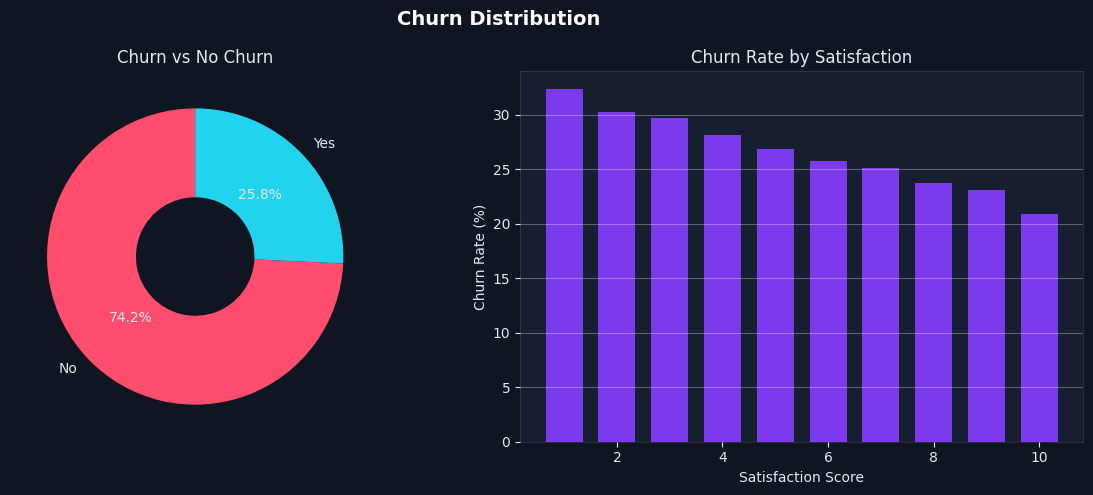

In [5]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('Churn Distribution', fontsize=14, fontweight='bold', color='white')

counts = df['Churn'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#ff4d6d','#22d3ee'], startangle=90,
            wedgeprops=dict(width=0.6))
axes[0].set_title('Churn vs No Churn')

churn_by_sat = df.groupby('Satisfaction_Score')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100)
axes[1].bar(churn_by_sat.index, churn_by_sat.values,
            color='#7c3aed', edgecolor='none', width=0.7)
axes[1].set_xlabel('Satisfaction Score')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Satisfaction')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../static/images/churn_dist.png', dpi=120, bbox_inches='tight')
plt.show()

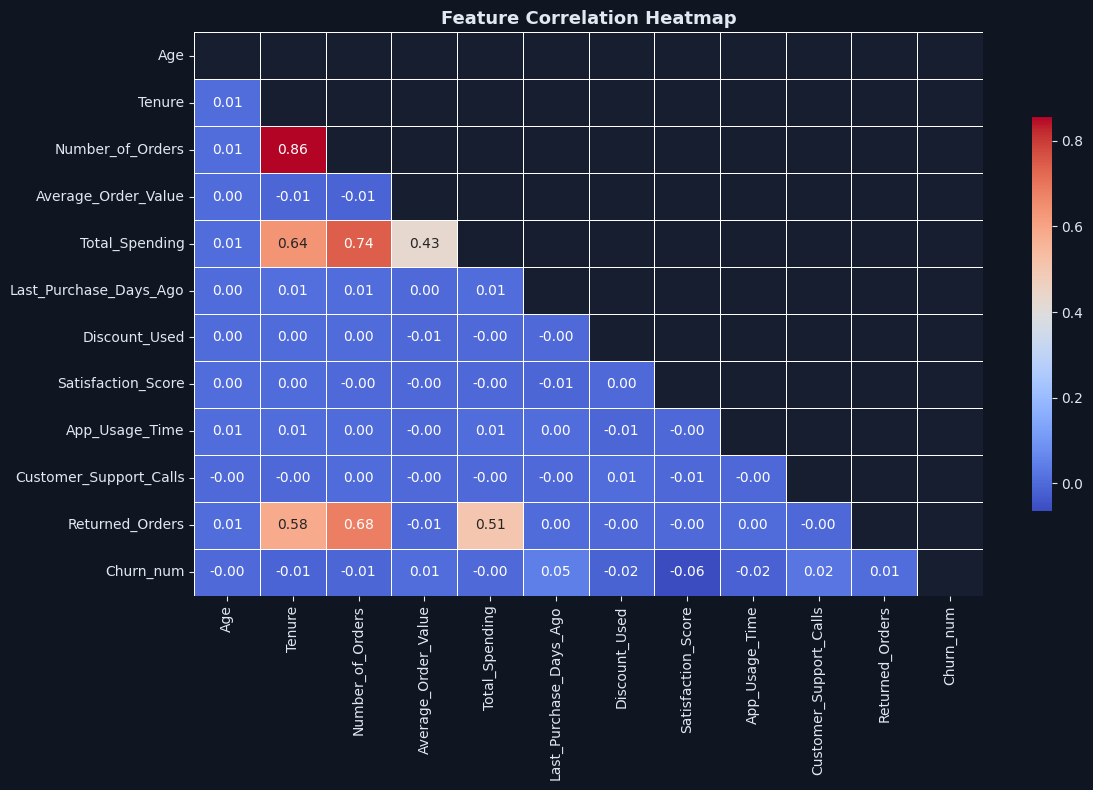

In [6]:
# Correlation Heatmap
df_num = df.select_dtypes(include=np.number).copy()
df_num['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(12,8))
mask = np.triu(np.ones_like(df_num.corr(), dtype=bool))
sns.heatmap(df_num.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../static/images/heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Feature Engineering & Encoding

In [7]:
df2 = df.drop(columns=['CustomerID']).copy()
df2['Churn'] = (df2['Churn'] == 'Yes').astype(int)

le_gender   = LabelEncoder()
le_location = LabelEncoder()
le_payment  = LabelEncoder()

df2['Gender']         = le_gender.fit_transform(df2['Gender'])
df2['Location']       = le_location.fit_transform(df2['Location'])
df2['Payment_Method'] = le_payment.fit_transform(df2['Payment_Method'])

# Derived features
df2['Orders_Per_Month']  = df2['Number_of_Orders'] / (df2['Tenure'] + 1)
df2['Avg_Spend_Per_Day'] = df2['Total_Spending'] / (df2['Last_Purchase_Days_Ago'] + 1)
df2['Return_Rate']       = df2['Returned_Orders'] / (df2['Number_of_Orders'] + 1)

print('✅ Feature engineering done. Shape:', df2.shape)
df2.head()

✅ Feature engineering done. Shape: (50000, 18)


,Age,Gender,Location,Tenure,Number_of_Orders,Average_Order_Value,Total_Spending,Last_Purchase_Days_Ago,Payment_Method,Discount_Used,Satisfaction_Score,App_Usage_Time,Customer_Support_Calls,Returned_Orders,Churn,Orders_Per_Month,Avg_Spend_Per_Day,Return_Rate
0,43,1,7,64,172,1062.61,189634.52,8,1,1,6,30.6,1,14,0,2.646154,21070.502222,0.080925
1,36,1,1,3,6,2087.05,10282.52,1,0,1,6,30.4,2,1,0,1.500000,5141.260000,0.142857
2,45,0,2,8,12,4653.05,52995.36,23,4,0,10,2.6,0,0,0,1.333333,2208.140000,0.000000
3,56,0,3,30,87,1685.99,119184.05,15,1,1,2,9.5,2,7,0,2.806452,7449.003125,0.079545
4,35,1,5,19,31,2232.96,63471.90,46,1,1,8,0.5,2,7,0,1.550000,1350.465957,0.218750


## 6. Model Building

In [8]:
feature_cols = [c for c in df2.columns if c != 'Churn']
X = df2[feature_cols]
y = df2['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_sc))
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
print(f'\nLogistic Regression  Acc: {lr_acc:.4f}  AUC: {lr_auc:.4f}')

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f'Random Forest        Acc: {rf_acc:.4f}  AUC: {rf_auc:.4f}')

Train: (40000, 17)  |  Test: (10000, 17)

Logistic Regression  Acc: 0.7425  AUC: 0.5509
Random Forest        Acc: 0.7415  AUC: 0.5256


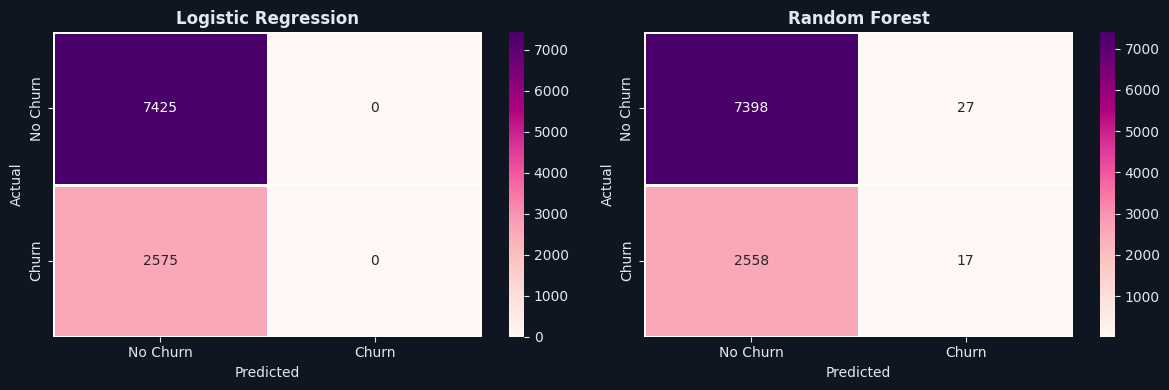


=== Random Forest Report ===
              precision    recall  f1-score   support

    No Churn       0.74      1.00      0.85      7425
       Churn       0.39      0.01      0.01      2575

    accuracy                           0.74     10000
   macro avg       0.56      0.50      0.43     10000
weighted avg       0.65      0.74      0.64     10000



In [9]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, model, preds, title in [
    (axes[0], lr, lr.predict(X_test_sc), 'Logistic Regression'),
    (axes[1], rf, rf.predict(X_test),    'Random Forest'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='RdPu', linewidths=1,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../static/images/confusion.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== Random Forest Report ===')
print(classification_report(y_test, rf.predict(X_test),
      target_names=['No Churn','Churn']))

## 7. Feature Importance

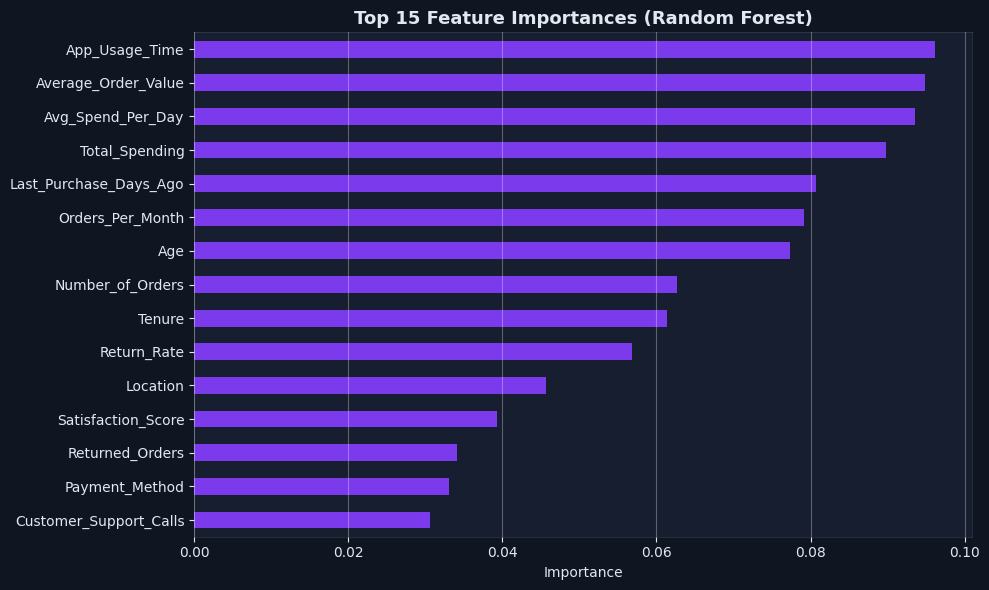

In [10]:
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10,6))
fi.tail(15).plot(kind='barh', ax=ax, color='#7c3aed', edgecolor='none')
ax.set_title('Top 15 Feature Importances (Random Forest)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../static/images/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Save Model Artifacts

In [11]:
best_model = rf if rf_acc >= lr_acc else lr
best_name  = 'Random Forest' if rf_acc >= lr_acc else 'Logistic Regression'
print(f'Best model: {best_name} ({max(rf_acc, lr_acc):.4f} accuracy)')

os.makedirs('../model', exist_ok=True)
joblib.dump(best_model, '../model/churn_model.pkl')
joblib.dump(scaler,      '../model/scaler.pkl')
joblib.dump(feature_cols,'../model/feature_cols.pkl')
joblib.dump({
    'le_gender': le_gender,
    'le_location': le_location,
    'le_payment': le_payment,
}, '../model/encoders.pkl')

# Stats JSON for dashboard
stats = {
    'total_customers': int(N),
    'churn_rate': float(round(churn.mean(), 4)),
    'churn_count': int(churn.sum()),
    'no_churn_count': int(N - churn.sum()),
    'model_accuracy': float(round(max(rf_acc, lr_acc), 4)),
    'best_model': best_name,
    'avg_age': float(round(ages.mean(), 1)),
    'avg_tenure': float(round(tenure.mean(), 1)),
    'avg_satisfaction': float(round(satisfaction_score.mean(), 2)),
    'churn_by_location': df.groupby('Location')['Churn']
        .apply(lambda x: round((x=='Yes').mean(), 3)).to_dict(),
    'churn_by_gender': df.groupby('Gender')['Churn']
        .apply(lambda x: round((x=='Yes').mean(), 3)).to_dict(),
    'payment_distribution': df['Payment_Method'].value_counts().to_dict(),
    'feature_importance': dict(zip(feature_cols, rf.feature_importances_.round(4).tolist())),
}
with open('../model/stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('\n✅ All artifacts saved to ../model/')

Best model: Logistic Regression (0.7425 accuracy)

✅ All artifacts saved to ../model/
